# 타이타닉 생존 예측: EDA 시각화 + 머신러닝 모델

목표: 승객 정보(성별, 등급, 나이, 요금 등)로 **생존 여부(0=사망, 1=생존)** 를 예측

1. 데이터 준비
2. EDA 시각화 (생존율 패턴 탐색)
3. 전처리 (결측치 처리, 파생 변수 생성)
4. 머신러닝 모델 학습 및 평가

셀 실행: `Shift + Enter`

## 1. 데이터 준비

컬럼명 오타 정리(`2urvived` → `Survived`) + 의미 없는 `zero*` 컬럼 제거

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

df = pd.read_csv("data/train_and_test2.csv")
df = df.rename(columns={"Passengerid": "PassengerId", "2urvived": "Survived"})
zero_cols = [c for c in df.columns if c.startswith("zero")]
df = df.drop(columns=zero_cols)
print(f"행: {df.shape[0]}, 열: {df.shape[1]}")
df.head()

행: 1309, 열: 9


,PassengerId,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


## 2. EDA 시각화

### 2-1. 생존자 분포 (타겟 변수)

Survived
0    967
1    342
Name: count, dtype: int64


C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py

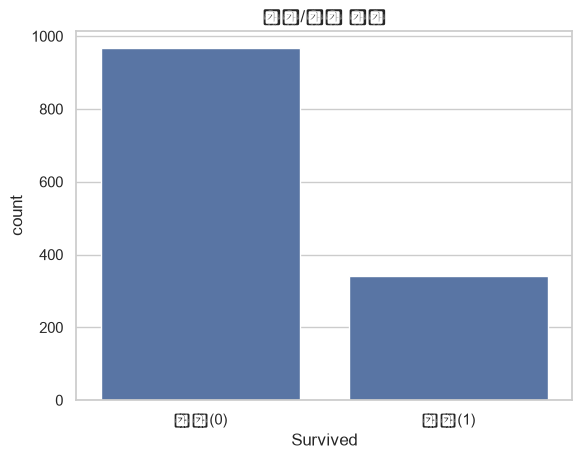

In [2]:
print(df["Survived"].value_counts())
sns.countplot(data=df, x="Survived")
plt.xticks([0, 1], ["사망(0)", "생존(1)"])
plt.title("생존/사망 분포")
plt.show()

### 2-2. 성별 / 객실등급 / 승선지별 생존율

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\3449678300.py:8: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\3449678300.py:8: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\3449678300.py:8: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\3449678300.py:8: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


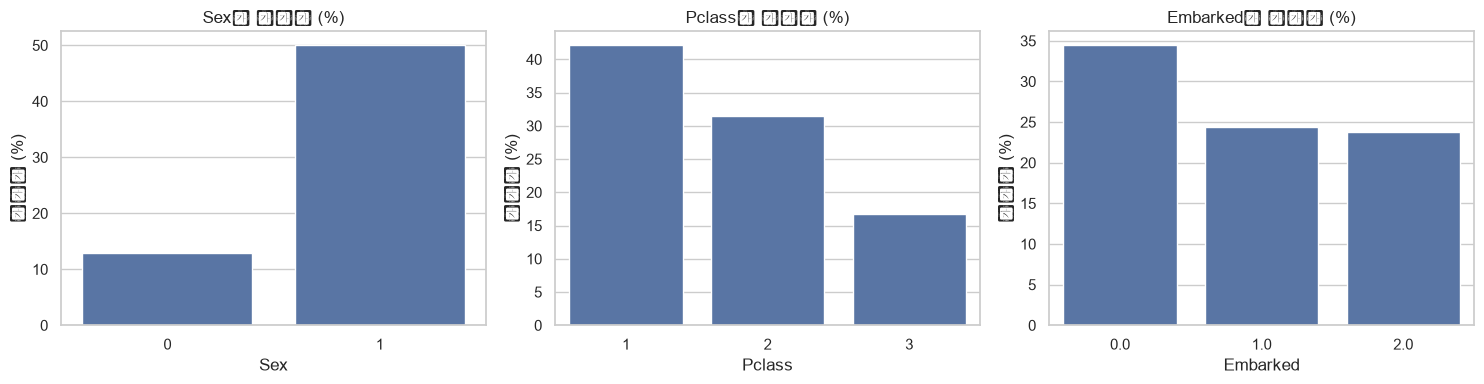

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Sex", "Pclass", "Embarked"]):
    rate = df.groupby(col)["Survived"].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"{col}별 생존율 (%)")
    ax.set_ylabel("생존율 (%)")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

**핵심 통찰**: 등급(Pclass) x 성별(Sex) 조합으로 생존율을 보면 패턴이 더 뚜렷함

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  fig.canv

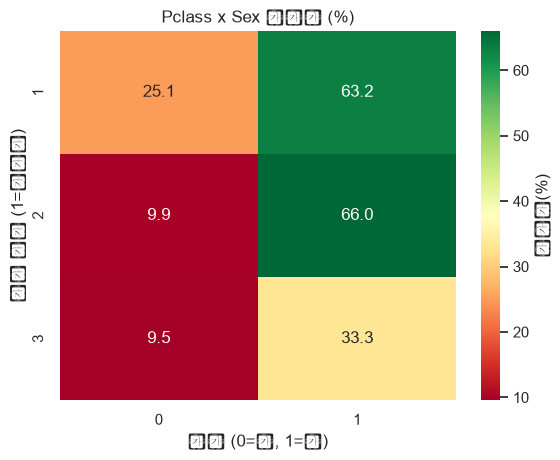

In [4]:
pivot = df.pivot_table(values="Survived", index="Pclass", columns="Sex", aggfunc="mean") * 100
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={"label": "생존율(%)"})
plt.title("Pclass x Sex 생존율 (%)")
plt.ylabel("객실 등급 (1=최고급)")
plt.xlabel("성별 (0=남, 1=여)")
plt.show()

### 2-3. 나이 / 요금 분포 (생존자 vs 사망자)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\1097465940.py:6: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\1097465940.py:6: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\1097465940.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\1097465940.py:6: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\1097465940.py:6: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\1097465940.py:6: UserWarning: Glyph 51316 (\N

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


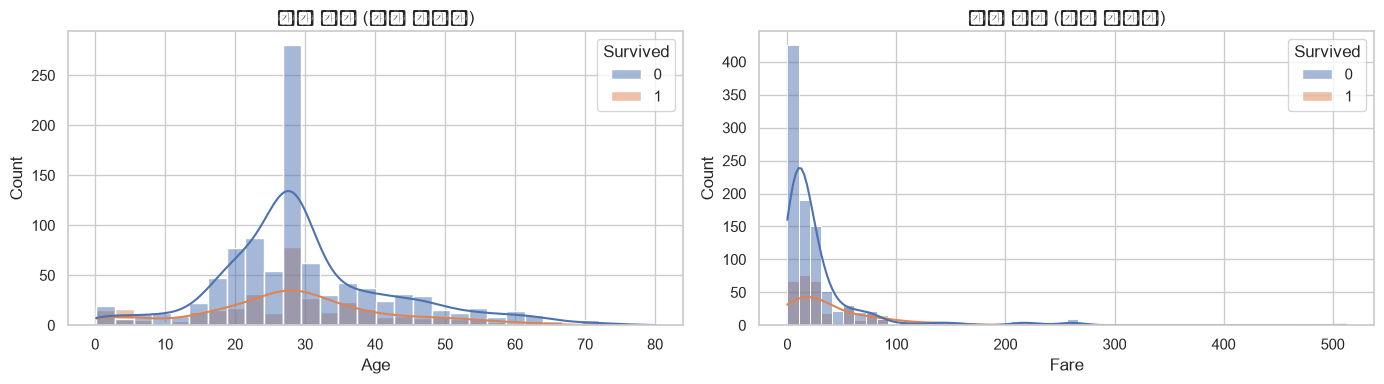

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True, ax=axes[0])
axes[0].set_title("나이 분포 (생존 여부별)")
sns.histplot(data=df, x="Fare", hue="Survived", bins=50, kde=True, ax=axes[1])
axes[1].set_title("요금 분포 (생존 여부별)")
plt.tight_layout()
plt.show()

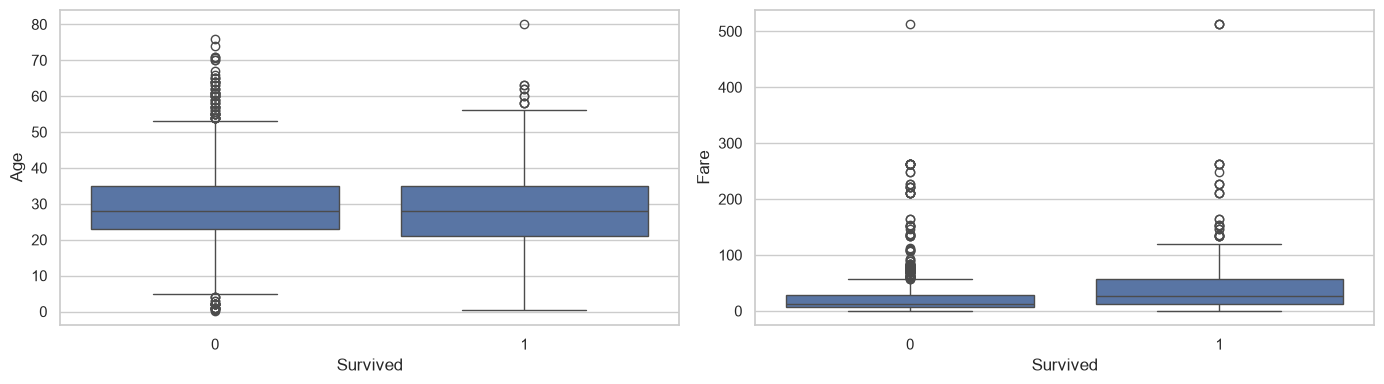

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x="Survived", y="Age", ax=axes[0])
sns.boxplot(data=df, x="Survived", y="Fare", ax=axes[1])
plt.tight_layout()
plt.show()

### 2-4. 동승 가족 수(sibsp, Parch)와 생존율

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\2735507341.py:7: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\2735507341.py:7: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\2735507341.py:7: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12732\2735507341.py:7: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314

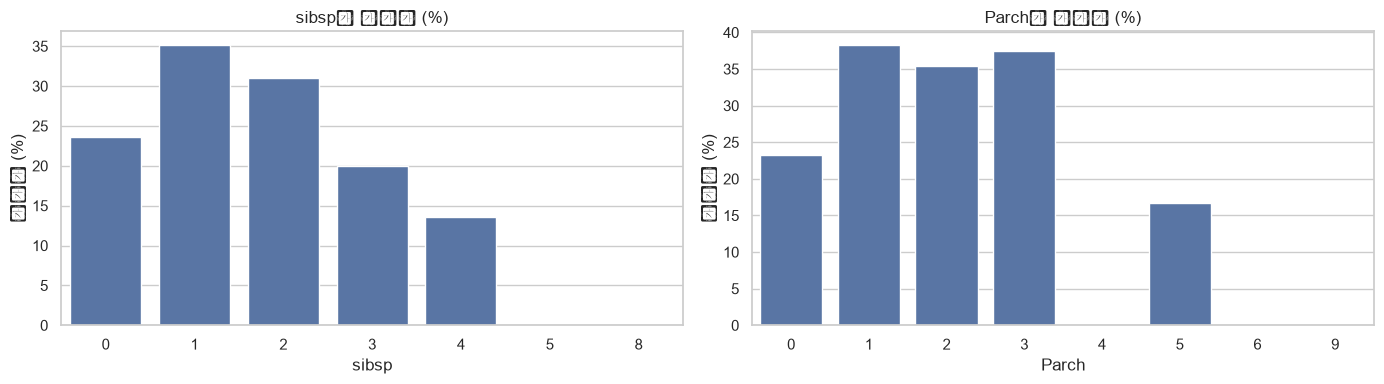

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ["sibsp", "Parch"]):
    rate = df.groupby(col)["Survived"].mean() * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"{col}별 생존율 (%)")
    ax.set_ylabel("생존율 (%)")
plt.tight_layout()
plt.show()

### 2-5. 변수 간 상관관계

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


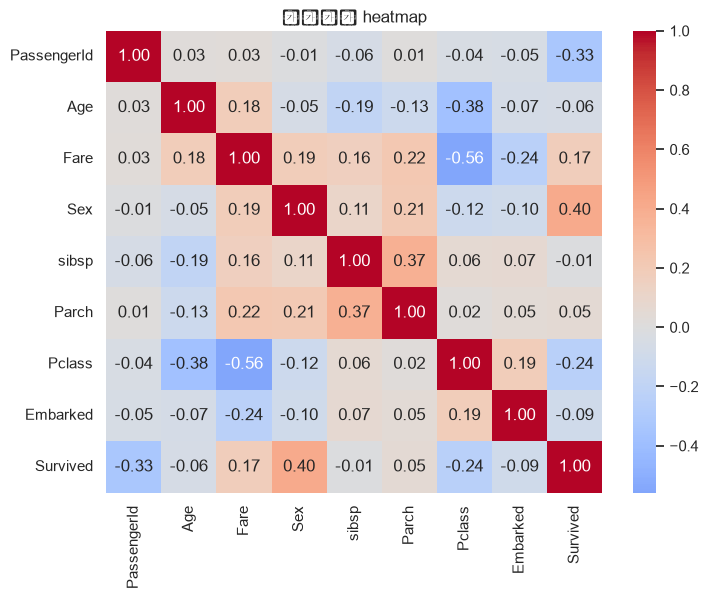

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("상관관계 heatmap")
plt.show()

## 3. 전처리

- `Embarked` 결측치 2개 → 최빈값으로 채움
- 파생 변수: `FamilySize`(가족 수), `IsAlone`(혼자 여부)
- `Embarked`(범주형) → 원-핫 인코딩

In [9]:
df_ml = df.copy()
df_ml["Embarked"] = df_ml["Embarked"].fillna(df_ml["Embarked"].mode()[0]).astype(int)
df_ml["FamilySize"] = df_ml["sibsp"] + df_ml["Parch"] + 1
df_ml["IsAlone"] = (df_ml["FamilySize"] == 1).astype(int)
df_ml = pd.get_dummies(df_ml, columns=["Embarked"], prefix="Emb").astype(int)

features = ["Pclass", "Sex", "Age", "Fare", "sibsp", "Parch", "FamilySize", "IsAlone", "Emb_0", "Emb_1", "Emb_2"]
X = df_ml[features]
y = df_ml["Survived"]
print(f"특성(feature) 개수: {X.shape[1]}, 샘플 수: {X.shape[0]}")
X.head()

특성(feature) 개수: 11, 샘플 수: 1309


,Pclass,Sex,Age,Fare,sibsp,Parch,FamilySize,IsAlone,Emb_0,Emb_1,Emb_2
0,3,0,22,7,1,0,2,0,0,0,1
1,1,1,38,71,1,0,2,0,1,0,0
2,3,1,26,7,0,0,1,1,0,0,1
3,1,1,35,53,1,0,2,0,0,0,1
4,3,0,35,8,0,0,1,1,0,0,1


## 4. 머신러닝 모델

### 4-1. 학습/테스트 분리 + 두 가지 모델 비교

- **LogisticRegression**: 선형 모델, 해석이 쉬움
- **RandomForest**: 나무 여러 개의 앙상블, 비선형 패턴까지 학습

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"학습 데이터: {len(X_train)}개, 테스트 데이터: {len(X_test)}개")

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = (model, pred)
    print(f"\n=== {name} ===")
    print(f"정확도(accuracy): {acc:.3f}")
    print(classification_report(y_test, pred, target_names=["사망", "생존"]))

학습 데이터: 1047개, 테스트 데이터: 262개

=== LogisticRegression ===
정확도(accuracy): 0.748
              precision    recall  f1-score   support

          사망       0.80      0.88      0.84       194
          생존       0.52      0.37      0.43        68

    accuracy                           0.75       262
   macro avg       0.66      0.62      0.63       262
weighted avg       0.73      0.75      0.73       262




=== RandomForest ===
정확도(accuracy): 0.779
              precision    recall  f1-score   support

          사망       0.85      0.86      0.85       194
          생존       0.58      0.56      0.57        68

    accuracy                           0.78       262
   macro avg       0.71      0.71      0.71       262
weighted avg       0.78      0.78      0.78       262



### 4-2. 혼동 행렬 (confusion matrix)

왼쪽 위(실제 사망, 예측 사망)와 오른쪽 아래(실제 생존, 예측 생존)가 많을수록 좋음

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:15

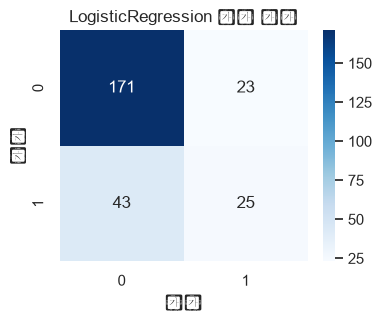

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:15

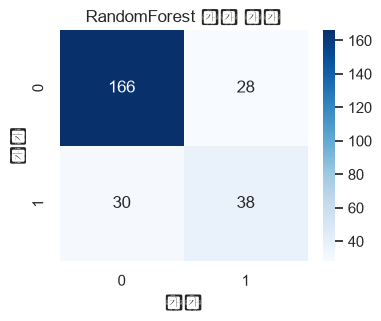

In [11]:
for name, (model, pred) in results.items():
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} 혼동 행렬")
    plt.xlabel("예측")
    plt.ylabel("실제")
    plt.show()

### 4-3. 교차 검증 (cross-validation)

데이터를 5등분해서 5번 학습/평가 → 우연에 의한 성능이 아닌지 확인 (더 신뢰할 수 있는 지표)

In [12]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model
                             
                             
                            , X, y, cv=5)
    print(f"{name} 5-fold CV 정확도: 평균 {scores.mean():.3f} (+/- {scores.std():.3f})")

LogisticRegression 5-fold CV 정확도: 평균 0.772 (+/- 0.053)


RandomForest 5-fold CV 정확도: 평균 0.744 (+/- 0.060)


### 4-4. 어떤 변수가 중요했을까? (feature importance)

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:

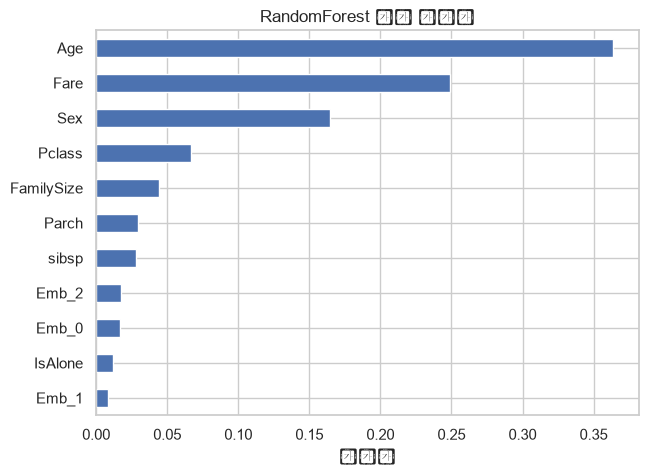

In [13]:
rf_model = models["RandomForest"]
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values()
importance.plot(kind="barh", figsize=(7, 5))
plt.title("RandomForest 변수 중요도")
plt.xlabel("중요도")
plt.show()

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py

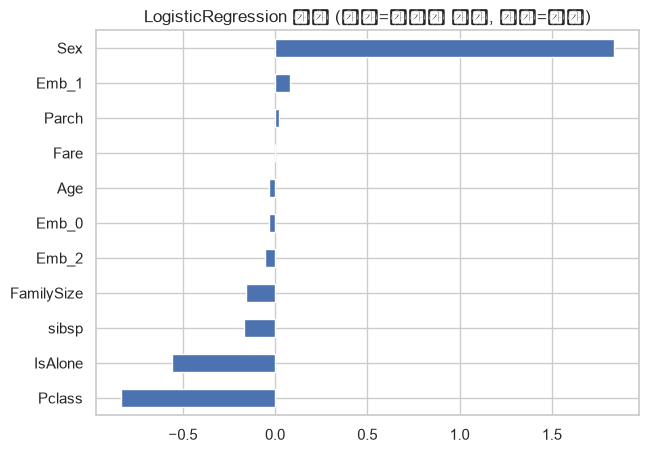

In [14]:
log_model = models["LogisticRegression"]
coef = pd.Series(log_model.coef_[0], index=features).sort_values()
coef.plot(kind="barh", figsize=(7, 5))
plt.title("LogisticRegression 계수 (양수=생존에 유리, 음수=불리)")
plt.show()

## 요약

- **EDA 결론**: 여성·1등석·어린아이·비싼 티켓일수록 생존율 높음, 남성·3등석 생존율 매우 낮음
- **모델 성능**: RandomForest가 대체로 더 높은 정확도 (~80%)
- **중요 변수**: Sex(성별)가 생존에 가장 큰 영향

다음 단계: 하이퍼파라미터 튜닝(GridSearchCV), Age 결측치 처리 방식 개선, 다른 데이터로 실습